# Research: how fit error changes with the number of points

This notebook sweeps a single injection across point counts from 3 to 15, stores coefficient values and uncertainties, and saves comparison plots in `research/output`.

In [6]:
from pathlib import Path
import importlib.util
import math
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pha_lib").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing pha_lib")


ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pha_lib import io
from pha_lib.timetrace import integrate_energy_window
from pha_lib.discharges import detect_injections

ADAPTIVE_PATH = ROOT / "adaptive point selection.py"
spec = importlib.util.spec_from_file_location("adaptive_point_selection", str(ADAPTIVE_PATH))
adaptive_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(adaptive_mod)

INPUT = ROOT / "data" / "test" / "modified" / "unitedc_62_239.txt"
OUT_DIR = ROOT / "research" / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

LINE_E = 6660.0
HALF_W = 60.0
CHANNEL_ID = 2
INJECTION_INDEX = 0
MIN_POINTS = 3
MAX_POINTS = 15

print(f"Project root: {ROOT}")
print(f"Output dir: {OUT_DIR}")
print(f"Input file: {INPUT}")

Project root: D:\ℱ Sci\IFPiLM\1st task
Output dir: D:\ℱ Sci\IFPiLM\1st task\research\output
Input file: D:\ℱ Sci\IFPiLM\1st task\data\test\modified\unitedc_62_239.txt


In [4]:
discharge = io.load_united_txt(INPUT, discharge_id="united_62_239")
channel = discharge.channels[CHANNEL_ID]
trace = integrate_energy_window(channel, LINE_E, HALF_W)
injections = detect_injections(trace, LINE_E)

if not injections:
    raise RuntimeError("No injections detected for the chosen channel")

if INJECTION_INDEX >= len(injections):
    raise IndexError(f"Requested injection index {INJECTION_INDEX} but only {len(injections)} injections were detected")

injection = injections[INJECTION_INDEX]
print(f"Loaded discharge: {discharge.discharge_id}")
print(f"Channel {CHANNEL_ID}: {len(injections)} injections detected")
print(f"Using injection #{injection.injection_no} spanning frames {injection.start_frame}..{injection.finish_frame}")

rows = adaptive_mod.sweep_injection_point_counts(
    trace,
    injection,
    min_points=MIN_POINTS,
    max_points=MAX_POINTS,
)
df = pd.DataFrame(rows)

cols_to_show = ["n_points", "success", "A", "A_err", "tau", "tau_err", "C", "C_err", "rss", "message"]
print(df[cols_to_show].to_string(index=False))

csv_path = OUT_DIR / f"sweep_channel{CHANNEL_ID}_inj{injection.injection_no}.csv"
df.to_csv(csv_path, index=False)
print(f"Saved table -> {csv_path}")

best_row = df[df["success"]].sort_values("rss").iloc[0]
print("")
print("Best fit by RSS:")
print(best_row[["n_points", "A", "A_err", "tau", "tau_err", "C", "C_err", "rss"]].to_string())

Loaded discharge: united_62_239
Channel 2: 4 injections detected
Using injection #1 spanning frames 64..68
 n_points  success          A     A_err      tau  tau_err    C  C_err         rss message
        3     True 162.884780  1.095464 0.978833 0.015552 64.0    0.0    1.213317      ok
        4     True 161.471728 12.182906 1.067812 0.176429 64.0    0.0  303.130681      ok
        5     True 161.118160 10.514507 1.086549 0.151941 64.0    0.0  339.922326      ok
        6     True 160.871052  9.793020 1.098629 0.142127 64.0    0.0  393.844419      ok
        7     True 160.793657  8.961085 1.102236 0.130246 64.0    0.0  412.426325      ok
        8     True 160.751442  8.397231 1.104144 0.122183 64.0    0.0  434.684171      ok
        9     True 160.739069  7.848172 1.104691 0.114232 64.0    0.0  443.008021      ok
       10     True 160.741154  7.350383 1.104600 0.106979 64.0    0.0  444.103256      ok
       11     True 160.743892  7.000785 1.104483 0.101882 64.0    0.0  453.216436  

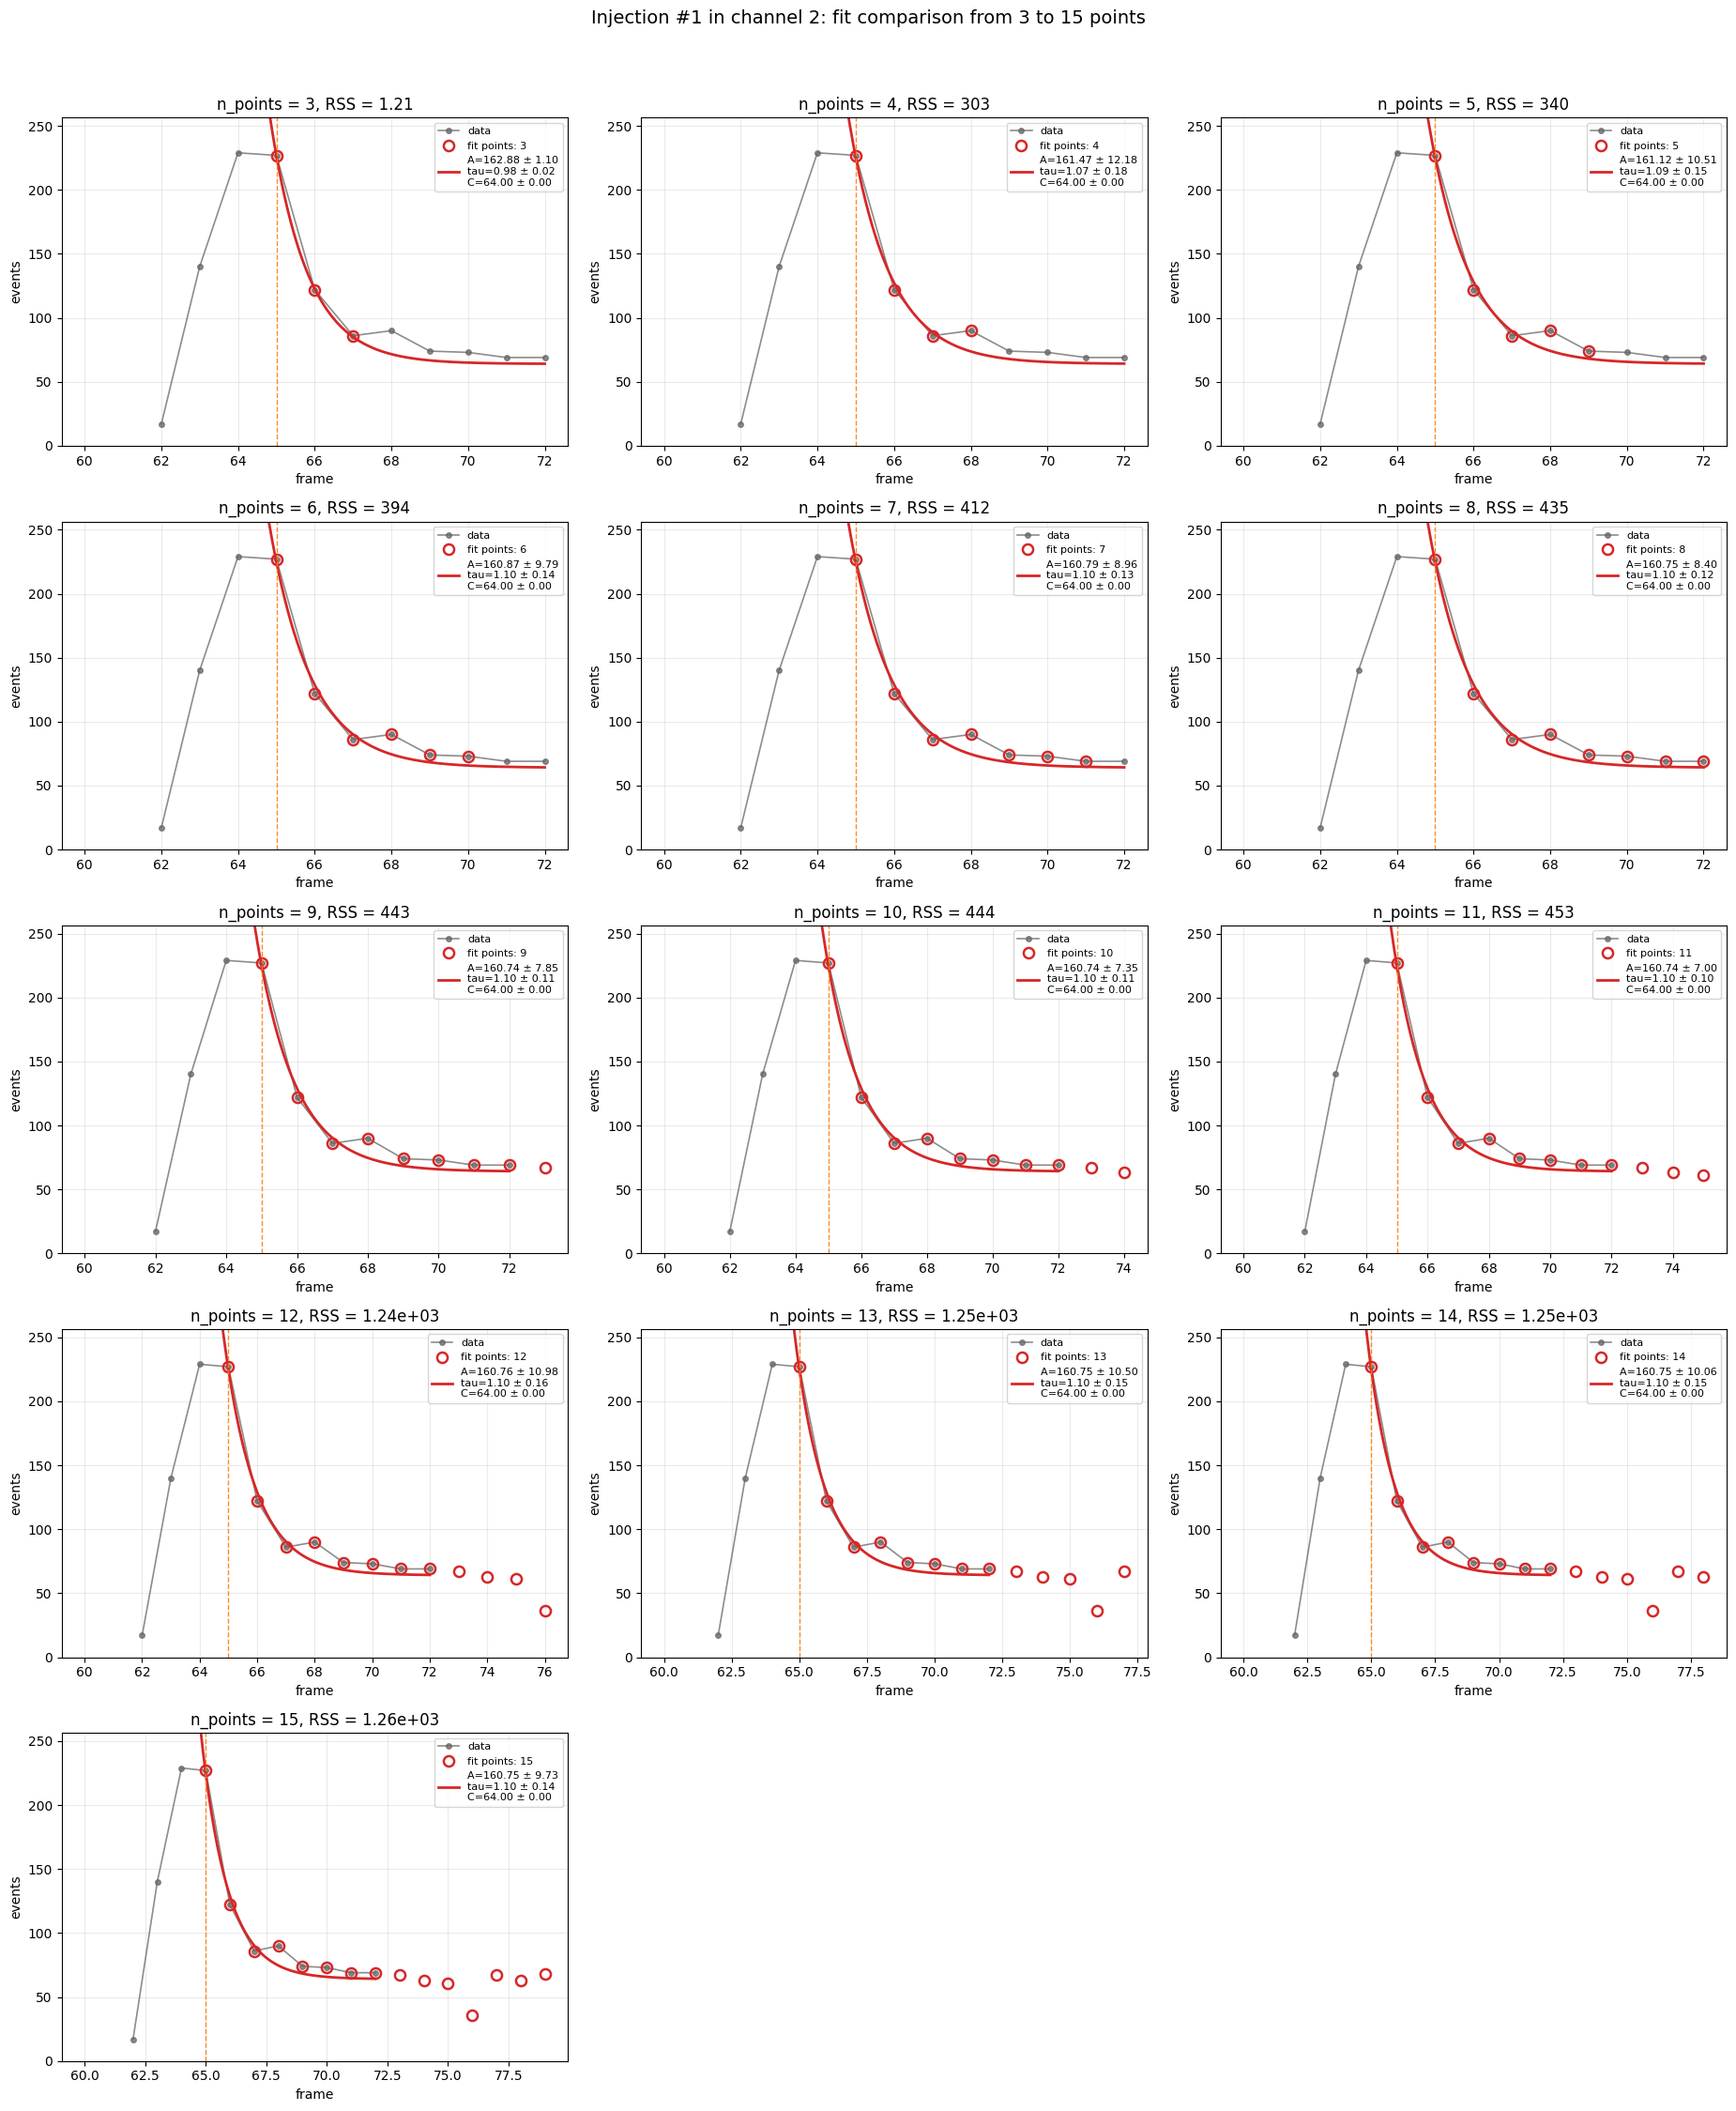

In [9]:
def format_value(value: float, error: float, digits: int = 2) -> str:
    if pd.isna(value):
        return "nan"
    if pd.isna(error):
        return f"{value:.{digits}f}"
    return f"{value:.{digits}f} ± {error:.{digits}f}"


success_df = df[df["success"]].copy().reset_index(drop=True)
if success_df.empty:
    raise RuntimeError("No successful fits were produced")

n_plots = len(success_df)
max_cols = 3
n_cols = min(max_cols, n_plots)
n_rows = math.ceil(n_plots / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.2 * n_cols, 4.4 * n_rows), squeeze=False)

fn = trace.frame_numbers
v = trace.values
start_idx = int(np.where(fn == int(injection.start_frame + 1))[0][0])
context_lo = max(0, injection.start_frame - 4)
context_hi = min(int(fn[-1]), injection.finish_frame + 4)
context_mask = (fn >= context_lo) & (fn <= context_hi)

for ax, (_, row) in zip(axes.flat, success_df.iterrows()):
    n_points = int(row["n_points"])
    end_idx = min(start_idx + n_points, len(fn))
    t_data = fn[start_idx:end_idx].astype(float)
    y_data = v[start_idx:end_idx]
    t_dense = np.linspace(context_lo, context_hi, 300)
    y_fit = row["A"] * np.exp(-(t_dense - row["t_0"]) / row["tau"]) + row["C"]

    ax.plot(fn[context_mask], v[context_mask], "o-", ms=4, lw=1.2, color="0.4", alpha=0.75, label="data")
    ax.plot(t_data, y_data, "o", ms=8, mfc="none", mec="tab:red", mew=1.8, label=f"fit points: {n_points}")
    ax.plot(
        t_dense,
        y_fit,
        color="tab:red",
        lw=2,
        label=(
            f"A={format_value(row['A'], row['A_err'])}\n"
            f"tau={format_value(row['tau'], row['tau_err'])}\n"
            f"C={format_value(row['C'], row['C_err'])}"
        ),
    )
    y_visible = np.r_[v[context_mask], y_data]
    y_max = float(np.max(y_visible)) * 1.12
    ax.set_ylim(0.0, y_max)
    ax.axvline(injection.start_frame + 1, color="tab:orange", ls="--", lw=1, alpha=0.9)
    ax.set_title(f"n_points = {n_points}, RSS = {row['rss']:.3g}")
    ax.set_xlabel("frame")
    ax.set_ylabel("events")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

for ax in axes.flat[n_plots:]:
    ax.axis("off")

fig.suptitle(
    f"Injection #{injection.injection_no} in channel {CHANNEL_ID}: fit comparison from {MIN_POINTS} to {MAX_POINTS} points",
    y=1.02,
    fontsize=14,
)
fig.tight_layout()
display(fig)
plt.close(fig)